In [2]:
from recbole.quick_start import load_data_and_model, run_recbole
import torch
import pandas as pd


import torch
from recbole.config import Config
from recbole.data import create_dataset, data_preparation

from recbole.model.general_recommender import NeuMF
from recbole.trainer import Trainer
from recbole.utils import get_model, get_trainer, init_seed, init_logger
from collections import defaultdict
import os
from recbole.quick_start import load_data_and_model
import rbo as rbo_lib

import rbo


/home/mvarasteh/.conda/envs/popsteer/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-20 14:09:57,255	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-05-20 14:09:57,536	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [3]:
import torch
import numpy as np
import pandas as pd
from collections import defaultdict

# ── 0. LOAD MODEL AND DATASET ───────────────────────────────────────────────
from recbole.quick_start import load_data_and_model

config, sasrec_model, dataset, train_data, valid_data, test_data = load_data_and_model(
    model_file='saved/sasrec_ml-1m.pth'
)
sasrec_model.eval()
device = config['device']

20 May 14:09    INFO  
General Hyper Parameters:
gpu_id = 0
use_gpu = True
seed = 2020
state = INFO
reproducibility = True
data_path = dataset/ml-1mm
checkpoint_dir = saved
show_progress = True
save_dataset = False
dataset_save_path = None
save_dataloaders = False
dataloaders_save_path = None
log_wandb = False

Training Hyper Parameters:
epochs = 300
train_batch_size = 2048
learner = adam
learning_rate = 0.001
train_neg_sample_args = {'distribution': 'none', 'sample_num': 'none', 'alpha': 'none', 'dynamic': False, 'candidate_num': 0}
eval_step = 1
stopping_step = 10
clip_grad_norm = None
weight_decay = 0.0
loss_decimal_place = 4

Evaluation Hyper Parameters:
eval_args = {'split': {'LS': 'valid_and_test'}, 'order': 'TO', 'group_by': 'user', 'mode': {'valid': 'full', 'test': 'full'}}
repeatable = True
metrics = ['Recall', 'NDCG', 'Hit', 'Deep_LT_Coverage', 'GiniIndex', 'AveragePopularity', 'ItemCoverage', 'NDCGTail', 'NDCGHead', 'NDCGMid']
topk = [10]
valid_metric = NDCG@10
valid_metric_

In [4]:

# ── 0. LOAD MODEL AND DATASET ───────────────────────────────────────────────
from recbole.quick_start import load_data_and_model

config, cbm_sasrec, dataset, train_data, valid_data, test_data = load_data_and_model(
    model_file='saved/SASRec_CBM-May-17-2026_16-33-02.pth'
)

cbm_sasrec.eval()
device = config['device']

20 May 14:10    INFO  
General Hyper Parameters:
gpu_id = 0
use_gpu = True
seed = 2020
state = INFO
reproducibility = True
data_path = ./dataset/ml-1mm
checkpoint_dir = saved
show_progress = True
save_dataset = False
dataset_save_path = None
save_dataloaders = False
dataloaders_save_path = None
log_wandb = True

Training Hyper Parameters:
epochs = 300
train_batch_size = 2048
learner = adam
learning_rate = 0.001
train_neg_sample_args = {'distribution': 'none', 'sample_num': 'none', 'alpha': 'none', 'dynamic': False, 'candidate_num': 0}
eval_step = 1
stopping_step = 300
clip_grad_norm = None
weight_decay = 0.0
loss_decimal_place = 4

Evaluation Hyper Parameters:
eval_args = {'split': {'LS': 'valid_and_test'}, 'order': 'TO', 'group_by': 'user', 'mode': {'valid': 'full', 'test': 'full'}}
repeatable = True
metrics = ['Recall', 'NDCG', 'MRR', 'Hit', 'ItemCoverage', 'GiniIndex', 'AveragePopularity', 'ConceptAccuracySoft', 'ConceptAccuracyStrict']
topk = [5, 10, 20]
valid_metric = NDCG@10
vali

[build] Building concept lookups...
  pop_set:   342 items (≥ 751 interactions)
  mid_set:   2725 items
  niche_set: 349 items (1–17 interactions)
  Items in metadata file: 3883, matched to internal IDs: 3416
  N_CONCEPTS = 25  (18 genres + 7 scalars)
  genres: ['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
[build] Computing per-item concept vectors for 3417 items...

[build] Saved per-item concept matrix ((3417, 25)) → ./dataset/ml-1mm/saved_concept_individual_items.pkl

[build] Diagnostics — items with NO ...
    ... genre features:  1 (should be ~1, padding)
    ... era features:    1 (only items missing year)
    ... tier features:   1 (only items w/ 0 interactions)
    mean genres/item:    1.00

[build] Spot check — item 1's concept vector:
    Drama                1.0000
    popularity           1.0000
    retro                1

## Steering by scaling factor

In [ ]:
import torch
import numpy as np
from recbole.quick_start import load_data_and_model
from recbole.trainer import Trainer
from recbole.evaluator import Collector, Evaluator



# ── Tier / genre / era lookups — adjust to where these live in your code ────
# (You computed these in build_concepts.py. Re-derive or import them.)
from recbole.utils.build_concepts import build_lookups
L = build_lookups(dataset, config['dataset'])

# Inject pools and concept lookups into config
config['popularity_pool'] = list(L['pop_set'])
config['mid_pool']        = list(L['mid_set'])
config['niche_pool']      = list(L['niche_set'])
config['item_to_genres']  = L['item_to_genres']
config['genre_list']      = L['genre_concepts']
config['item_to_era']     = L['item_to_era']
# era_list defaults inside YearExposure if not set

# Configure metric list — auto-discovered, lowercase names work
config['metrics'] = ['Recall', 'NDCG', 'Hit', 'MRR',
                     'ItemCoverage', 'GiniIndex', 'AveragePopularity',
                      'GenreExposure', 'YearExposure','TierExposure']
config['topk']    = [10]
config['valid_metric'] = 'NDCG@10'



def evaluate_with_recbole_sasrec(model, config, train_data, test_data):
    
    """Set steering on the model and run RecBole eval. Tier/genre/year exposure
    metrics are reported automatically alongside standard rec metrics."""
   
    model.steer_concept_idx = None
    model.steer_scale       = 1.0

    trainer = Trainer(config, model)
    trainer.eval_collector = Collector(config)
    trainer.evaluator      = Evaluator(config)
    trainer.eval_collector.data_collect(train_data)

    result = trainer.evaluate(test_data, load_best_model=False, show_progress=False)

 
    return result


def evaluate_with_recbole(cbm, config, train_data, test_data,
                          concept_idx=None, scale=1.0):
    """Set steering on the model and run RecBole eval. Tier/genre/year exposure
    metrics are reported automatically alongside standard rec metrics."""
    cbm.steer_concept_idx = concept_idx
    #config['steer_concept_idx'] = concept_idx
    cbm.steer_scale       = scale
    #config['steer_scale']       = scale
   

    trainer = Trainer(config, cbm)
    trainer.eval_collector = Collector(config)
    trainer.evaluator      = Evaluator(config)
    trainer.eval_collector.data_collect(train_data)

    result = trainer.evaluate(test_data, load_best_model=False, show_progress=False)

    cbm.steer_concept_idx = None
    #config['steer_concept_idx'] = None
    cbm.steer_scale       = 1.0
    #config['steer_scale' ]      = 1.0
    return result




# ── Run baseline ─────────────────────────────────────────────────────────────
print("Evaluating baseline...")
base_result = evaluate_with_recbole_sasrec(sasrec_model, config, train_data, test_data)



CONCEPT_NAME = 'popularity'   

SCALE        = 0.8

idx = cbm_sasrec.concept_names.index(CONCEPT_NAME)

#print(f"\nEvaluating steered ({CONCEPT_NAME} idx={idx}, scale={SCALE})...")
steer_result = evaluate_with_recbole(cbm_sasrec, config, train_data, test_data,
                                      concept_idx=idx, scale=SCALE )

# ── Print comparison ─────────────────────────────────────────────────────────
print(f"\n{'Metric':<35} {'Baseline':>12} {'Steered':>12} {'Δ':>12}")
for k in base_result:
    b, s = base_result[k], steer_result[k]
    print(f"{k:<35} {b:>12.4f} {s:>12.4f} {s-b:>+12.4f}")

## RBO comparison

In [ ]:


@torch.no_grad()
def get_top_k_recommendations(model, data_loader, k=20, exclude_seen=True):
    """
    Returns {internal_user_id: LongTensor[k]} of top-k recommended INTERNAL
    item ids, ranked best-first.

    Compatible with compare_recommendations(): each value is a tensor on which
    .numpy().tolist() works.

    exclude_seen=True masks items already in the user's history before ranking,
    matching RecBole's default full-sort eval protocol. Set False only if your
    reported Recall/NDCG were computed WITHOUT seen-item masking.
    """
    model.eval()
    device = next(model.parameters()).device
    recs = {}

    for batch in data_loader:
        interaction = batch[0] if isinstance(batch, (list, tuple)) else batch
        interaction = interaction.to(device)

        # [B, n_items] full-catalog scores
        scores = model.full_sort_predict(interaction)
        B = interaction[model.ITEM_SEQ].shape[0]
        scores = scores.view(B, -1).clone()

        # mask padding item (internal id 0)
        scores[:, 0] = -float('inf')

        if exclude_seen:
            item_seq = interaction[model.ITEM_SEQ]
            for i in range(B):
                seen = item_seq[i][item_seq[i] != 0]
                scores[i, seen] = -float('inf')

        topk = torch.topk(scores, k, dim=1).indices          # [B, k] internal ids

        uids = interaction[model.USER_ID].tolist()
        for u, row in zip(uids, topk):
            recs[u] = row.detach().cpu()

    return recs

In [ ]:


def compare_recommendations(recs_sasrec, recs_cbm, k=20, p=0.9):
    """
    Compare top-k recommendations between two models.
    Computes per-user RBO, Jaccard, and overlap count.
    """
    rbo_scores     = []
    jaccard_scores = []
    overlap_counts = []
    
    common_users = set(recs_sasrec.keys()) & set(recs_cbm.keys())
    
    for user_idx in sorted(common_users):
        list_a = recs_sasrec[user_idx].numpy().tolist()
        list_b = recs_cbm[user_idx].numpy().tolist()
        
        set_a = set(list_a)
        set_b = set(list_b)
        
        intersection = len(set_a & set_b)
        union        = len(set_a | set_b)
        
        jaccard = intersection / union if union > 0 else 0
        rbo_val     = rbo.RankingSimilarity(list_a, list_b).rbo()
        
        rbo_scores.append(rbo_val )
        jaccard_scores.append(jaccard)
        overlap_counts.append(intersection)
    
    rbo_scores     = np.array(rbo_scores)
    jaccard_scores = np.array(jaccard_scores)
    overlap_counts = np.array(overlap_counts)
    
    print(f"\n{'='*60}")
    print(f"Top-{k} Recommendation Comparison: SASRec vs CBM")
    print(f"{'='*60}")
    print(f"  Users compared:        {len(common_users)}")
    print(f"  Mean RBO (p={p}):       {rbo_scores.mean():.4f}")
    print(f"  Median RBO:            {np.median(rbo_scores):.4f}")
    print(f"  Mean Jaccard:          {jaccard_scores.mean():.4f}")
    print(f"  Median Jaccard:        {np.median(jaccard_scores):.4f}")
    print(f"  Mean overlap (/{k}):    {overlap_counts.mean():.1f}")
    print(f"  Median overlap (/{k}):  {np.median(overlap_counts):.1f}")
    print(f"  Perfect match (={k}):   {(overlap_counts == k).sum()} users")
    print(f"  Zero overlap (=0):     {(overlap_counts == 0).sum()} users")
    
    print(f"\n  Overlap distribution:")
    for threshold in [0, 5, 10, 15, 20]:
        count = (overlap_counts >= threshold).sum()
        pct = 100 * count / len(overlap_counts)
        print(f"    ≥{threshold:2d} items overlap:  {count:5d} users ({pct:.1f}%)")
    
    return rbo_scores, jaccard_scores, overlap_counts


recs_sasrec = get_top_k_recommendations(sasrec_model, test_data, k=20)
recs_cbm    = get_top_k_recommendations(cbm_sasrec, test_data, k=20)

rbo_scores, jaccard_scores, overlap_counts = compare_recommendations(recs_sasrec, recs_cbm, k=20, p=0.9)

## H and H_hat similarity

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from scipy.stats import spearmanr


@torch.no_grad()
def collect_h_hhat(cbm_model, data_loader, device=None):
    """
    Run the CBM over a data loader and collect the frozen-SASRec embedding `h`
    and the reconstructed embedding `h_hat` for every batch.

    Returns two tensors: H [N, hidden], H_hat [N, hidden]  (on CPU).
    """
    if device is None:
        device = next(cbm_model.parameters()).device

    cbm_model.eval()
    H, H_hat = [], []

    for batch in data_loader:
        # RecBole loaders yield an Interaction (or a tuple where it's first)

        interaction = batch[0] if isinstance(batch, (list, tuple)) else batch
        interaction = interaction.to(device)

        item_seq     = interaction[cbm_model.ITEM_SEQ]
        item_seq_len = interaction[cbm_model.ITEM_SEQ_LEN]
        

        h, c_hat, h_hat = cbm_model.forward(item_seq, item_seq_len)
        H.append(h.detach().cpu())
        H_hat.append(h_hat.detach().cpu())

    return torch.cat(H, dim=0), torch.cat(H_hat, dim=0)


def embedding_similarity_report(H, H_hat, item_embeddings=None, n_score_sample=2000):
    """
    H, H_hat : [N, hidden] tensors (the same N rows, aligned).
    item_embeddings : optional [n_items, hidden] tensor — if given, also reports
                      how similarly h and h_hat *rank* items (Spearman of scores).

    Prints a report and returns a dict of metrics.
    """
    assert H.shape == H_hat.shape, f"shape mismatch {H.shape} vs {H_hat.shape}"
    N, D = H.shape
    Hf, Hhf = H.float(), H_hat.float()

    # ── 1. Per-row cosine similarity (direction) ─────────────────────────────
    cos = F.cosine_similarity(Hf, Hhf, dim=-1)              # [N]

  
    

    # ── 5. Coefficient of determination R^2 (variance explained) ─────────────
    ss_res = ((Hf - Hhf) ** 2).sum()
    ss_tot = ((Hf - Hf.mean()) ** 2).sum()

    metrics = {
        'cosine_mean':      cos.mean().item(),
        'cosine_median':    cos.median().item(),
        'cosine_std':       cos.std().item(),
      
    }

    print(f"\n{'='*60}")
    print(f"Embedding similarity:  h  vs  h_hat   (N={N}, dim={D})")
    print(f"{'='*60}")
    print(f"  Cosine    mean={metrics['cosine_mean']:.4f}  "
          f"median={metrics['cosine_median']:.4f}  "
          f"std={metrics['cosine_std']:.4f}")
   



    print(f"{'='*60}\n")
    return metrics

In [ ]:

H, H_hat = collect_h_hhat(cbm_sasrec, test_data)

metrics = embedding_similarity_report(
    H, H_hat,
    item_embeddings=cbm_sasrec.item_embedding.weight,   # ties it back to ranking
)

## Steering by activation engineering

In [5]:
import torch
import numpy as np
from collections import defaultdict


@torch.no_grad()
def build_concept_activations(sasrec, concept_pools, n_synthetic_users=1000,
                              seq_length=50, device='cuda', batch_size=128):
    
    """
    For each concept, generate synthetic user histories from that concept's item pool,
    feed them through SASRec, and average the last-layer hidden state. The result is
    a "concept direction" in SASRec's representation space.
    
    Args:
        sasrec: trained SASRec model (or SASRec_CBM — uses its frozen encoder)
        concept_pools: dict {concept_name: set/list of internal item IDs}
            e.g. {'popularity': {1, 5, 12, ...}, 'comedy': {3, 7, ...}, ...}
        n_synthetic_users: number of synthetic histories per concept
        seq_length: length of each synthetic history
        device: 'cuda' or 'cpu'
        batch_size: how many synthetic histories to forward at once
    
    Returns:
        dict {concept_name: torch.Tensor of shape [hidden_size]}
            — the mean activation vector for that concept
    """

    sasrec.eval()
    sasrec = sasrec.to(device)
    
    concept_activations = {}
    
    for concept_name, item_pool in concept_pools.items():
        # Convert pool to numpy array for fast sampling
        pool_arr = np.array(list(item_pool), dtype=np.int64)
        
        if len(pool_arr) == 0:
            print(f"[skip] {concept_name}: empty pool")
            continue
        
        # ── Generate n_synthetic_users sequences ─────────────────────────────
        # Each sequence is `seq_length` items sampled (with replacement) from the pool.
        # Sampling with replacement is fine — we want a "pure" concept signal.
        rng = np.random.default_rng(seed=42)
        seqs = rng.choice(pool_arr, size=(n_synthetic_users, seq_length), replace=True)
        print(f"seq_lens {seqs} ")
        seq_lens = np.full(n_synthetic_users, seq_length, dtype=np.int64)
        
        # ── Forward in batches ───────────────────────────────────────────────
        all_h = []
        for start in range(0, n_synthetic_users, batch_size):
            end = min(start + batch_size, n_synthetic_users)
            item_seq     = torch.from_numpy(seqs[start:end]).long().to(device)
            item_seq_len = torch.from_numpy(seq_lens[start:end]).long().to(device)
            
            # Use SASRec's forward — returns hidden state h of shape [B, hidden_size]
            # For SASRec_CBM, this is what _encode produces
            
            h = sasrec.forward(item_seq, item_seq_len)  
            print(f"  [shape check] h={tuple(h.shape)}")      # vanilla SASRec
            
            all_h.append(h.cpu())
            
        

        # ── Mean across all synthetic users for this concept ─────────────────
        all_h = torch.cat(all_h, dim=0)                          # [n_synthetic_users, hidden_size]
        mean_h = all_h.mean(dim=0)                                # [hidden_size]
        
        concept_activations[concept_name] = mean_h

        print(f"[done] {concept_name}: pool_size={len(pool_arr):>5d}, "
              f"mean_h norm={mean_h.norm().item():.4f}")
    
    return concept_activations




# ── BUILD CONCEPT POOLS FOR ML-1MM ──────────────────────────────────────────
# Combines tier pools (pop/mid/niche) + per-genre pools + per-era pools



def build_concept_pools(dataset, dataset_name='ml-1mm'):
    """
    Build a dict mapping concept name → set of internal item IDs.
    Combines popularity tiers, genres, and eras into a single dict.
    """
    from recbole.utils.build_concepts import build_lookups
    L = build_lookups(dataset, dataset_name)
    pools = {}
    
    # Popularity tiers
    pools['popularity'] = L['pop_set']
    pools['mid']        = L['mid_set']
    pools['niche']      = L['niche_set']
    
    
    # Per-genre pools (items having that genre)
    for genre in L['genre_concepts']:
        items_with_genre = {
            iid for iid, genres in L['item_to_genres'].items()
            if genre in genres
        }
        pools[genre] = items_with_genre
    

    # Per-era pools
    era_to_items = defaultdict(set)
    for iid, era in L['item_to_era'].items():
        if era is not None:
            era_to_items[era].add(iid)
    for era, items in era_to_items.items():
        pools[era] = items
    
    return pools




# ── USAGE ───────────────────────────────────────────────────────────────────
# Assume: cbm_sasrec, dataset already loaded

concept_pools = build_concept_pools(dataset, dataset_name='ml-1mm')

# Report pool sizes
print(f"\n{'Concept':<20} {'Pool size':>10}")
print("─" * 32)
for name, pool in concept_pools.items():
    print(f"{name:<20} {len(pool):>10}")

# Compute concept activations
print(f"\nComputing concept activations from synthetic users...")
concept_activations = build_concept_activations(
    sasrec_model,
    concept_pools,
    n_synthetic_users=1000,
    seq_length=50,
    device=device,
    batch_size=512,
)

# Now concept_activations is a dict: {concept_name: tensor of shape [128]}
print(f"\nGot {len(concept_activations)} concept activation vectors of shape "
      f"{next(iter(concept_activations.values())).shape}")

  pop_set:   343 items (≥ 760 interactions)
  mid_set:   2716 items
  niche_set: 357 items (1–18 interactions)
  Items in metadata file: 3883, matched to internal IDs: 3416


  N_CONCEPTS = 25  (18 genres + 7 scalars)
  genres: ['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

Concept               Pool size
────────────────────────────────
popularity                  343
mid                        2716
niche                       357
Action                      119
Adventure                    23
Animation                   104
Children's                  162
Comedy                      642
Crime                       158
Documentary                  84
Drama                       649
Fantasy                      22
Film-Noir                    41
Horror                      315
Musical                      69
Mystery                      78
Romance                     363
Sci-Fi                      191
Thriller                    218
War                         119
Western                      59
modern  

In [ ]:
import torch
import numpy as np
import csv
from recbole.trainer import Trainer
from recbole.evaluator import Collector, Evaluator
from recbole.utils.build_concepts import build_lookups


# ── 0. Set up config — must run BEFORE any evaluation ────────────────────────

# Inject lookups needed by exposure metrics
L = build_lookups(dataset, config['dataset'])
config['popularity_pool'] = list(L['pop_set'])
config['mid_pool']        = list(L['mid_set'])
config['niche_pool']      = list(L['niche_set'])
config['item_to_genres']  = L['item_to_genres']
config['genre_list']      = L['genre_concepts']
config['item_to_era']     = L['item_to_era']



# Configure metric set
config['metrics'] = ['Recall', 'NDCG', 'Hit', 'MRR',
                     'ItemCoverage', 'GiniIndex', 'AveragePopularity',
                     'TierExposure', 'YearExposure', 'GenreExposure']
config['topk']         = [10]
config['valid_metric'] = 'NDCG@10'


# ── 1. Build steering vector from two contrastive concepts ───────────────────
def build_steering_vector(concept_activations, positive_concept, negative_concept):
    """Steering vector points FROM negative_concept TOWARD positive_concept."""
    if positive_concept not in concept_activations:
        raise KeyError(f"'{positive_concept}' not in concept_activations")
    if negative_concept not in concept_activations:
        raise KeyError(f"'{negative_concept}' not in concept_activations")
    return concept_activations[positive_concept] - concept_activations[negative_concept]


# ── 2. Activation steering wrapper (vanilla SASRec only) ─────────────────────
class ActivationSteeredSASRec:
    """
    Wraps a vanilla SASRec to apply activation steering at inference.
    Monkey-patches `forward` so the returned sequence representation `h`
    is shifted by `alpha * steering_vector`.
    """

    def __init__(self, model, steering_vector, alpha=1.0):
        self.model             = model
        self.steering_vector   = steering_vector.to(next(model.parameters()).device)
        self.alpha             = alpha
        self._original_forward = model.forward

    def enable(self):
        v        = self.steering_vector
        alpha    = self.alpha
        original = self._original_forward

        def patched_forward(item_seq, item_seq_len):
            h = original(item_seq, item_seq_len)
            #if not hasattr(patched_forward, '_checked'):
             #   print(f"  [shape check] h={tuple(h.shape)}  v={tuple(v.shape)}")
              #  assert h.shape[-1] == v.shape[-1], \
               #     f"DIM MISMATCH: h is {h.shape[-1]}-dim, v is {v.shape[-1]}-dim — not the same space!"
                #patched_forward._checked = True
            return h + alpha * v.unsqueeze(0)

        self.model.forward = patched_forward

    def disable(self):
        self.model.forward = self._original_forward


# ── 3. Evaluation function with optional activation steering ─────────────────
def evaluate_with_steering_sasrec(model, config, train_data, test_data
            ):
    """Run RecBole evaluation, optionally with activation steering applied.

    Steering is only intended for vanilla SASRec. If a steering_vector is
    passed, `model.forward` is monkey-patched for the duration of the
    evaluation and restored afterwards (even on error).
    """
   
       

    trainer = Trainer(config, model)
    trainer.eval_collector = Collector(config)
    trainer.evaluator      = Evaluator(config)
    trainer.eval_collector.data_collect(train_data)

    result = trainer.evaluate(test_data, load_best_model=False, show_progress=False)
    

    return result

def evaluate_with_steering(model, config, train_data, test_data,
                           steering_vector=None, alpha=1.0):
    """Run RecBole evaluation, optionally with activation steering applied.

    Steering is only intended for vanilla SASRec. If a steering_vector is
    passed, `model.forward` is monkey-patched for the duration of the
    evaluation and restored afterwards (even on error).
    """
 
        
    steerer = ActivationSteeredSASRec(model, steering_vector, alpha=alpha)
    steerer.enable()


       

    trainer = Trainer(config, model)
    trainer.eval_collector = Collector(config)
    trainer.evaluator      = Evaluator(config)
    trainer.eval_collector.data_collect(train_data)

    result = trainer.evaluate(test_data, load_best_model=False, show_progress=True)
   
    steerer.disable()

    return result


# ── 4. Define steering sweeps ────────────────────────────────────────────────
steering_pairs = [
    # (label,                       positive_concept, negative_concept)
    ('niche ← popularity',          'niche',          'popularity'),
    ('mid ← popularity',            'mid',            'popularity'),
    ('Comedy ← Drama',              'Comedy',         'Drama'),
    ('Horror ← Comedy',             'Horror',         'Comedy'),
    ('classic ← modern',      'classic',        'modern'),
]

alphas = [0.05]    # baseline (α=0) handled separately

all_results = {}


# ── 5. Run baseline + steered evaluations ────────────────────────────────────
print("Evaluating BASELINE (no steering)")
all_results['baseline'] = evaluate_with_steering_sasrec(
    sasrec_model, config, train_data, test_data
    
)
print("Baseline results:", all_results['baseline'])


pos_concept='mid'
neg_concept='popularity'
v = build_steering_vector(concept_activations, pos_concept, neg_concept)

all_results = evaluate_with_steering(
            sasrec_model, config, train_data, test_data,
            steering_vector=v, alpha=0.1,
        )

print("Steering results:", all_results)

'''

for label, pos_concept, neg_concept in steering_pairs:
    v = build_steering_vector(concept_activations, pos_concept, neg_concept)
    print(f"\n[steer vector ||v||={v.norm().item():.4f}] {label}")

    for alpha in alphas:
        key = f'{label} α={alpha}'
        print("=" * 70)
        print(f"Evaluating: {key}")
        print("=" * 70)
        print('key:',key)
        all_results[key] = evaluate_with_steering(
            sasrec_model, config, train_data, test_data,
            steering_vector=v, alpha=alpha,
        )


# ── 6. Print results — grouped by metric type ────────────────────────────────

def print_table(title, all_results, baseline, metrics_to_show):
    """Print a comparison table for a given metric group."""
    width_per_col = 22
    total_width   = 32 + width_per_col * len(metrics_to_show)

    print("\n" + "=" * total_width)
    print(title)
    print("=" * total_width)

    header = f"{'Setting':<32}" + ''.join(f"{m:>{width_per_col}}" for m in metrics_to_show)
    print(header)
    print('─' * total_width)

    for key, result in all_results.items():
        row = f"{key:<32}"
        for m in metrics_to_show:
            v = result.get(m, float('nan'))
            if key == 'baseline':
                row += f"{v:>{width_per_col}.4f}"
            else:
                b = baseline.get(m, float('nan'))
                delta = v - b
                row += f"{v:>14.4f}({delta:+6.3f})"
        print(row)


baseline = all_results['baseline']
topk = config['topk'][0]


# Table 1: Rec quality + popularity tier exposure
print_table(
    "1. REC QUALITY + POPULARITY TIER EXPOSURE",
    all_results, baseline,
    metrics_to_show=[
        f'recall@{topk}', f'ndcg@{topk}', f'hit@{topk}', f'mrr@{topk}',
        f'itemcoverage@{topk}', f'giniindex@{topk}', f'averagepopularity@{topk}',
        f'pop_rate@{topk}', f'mid_rate@{topk}', f'niche_rate@{topk}',
    ],
)


# Table 2: Era exposure
print_table(
    "2. ERA EXPOSURE",
    all_results, baseline,
    metrics_to_show=[
        f'era_classic_rate@{topk}',
        f'era_retro_rate@{topk}',
        f'era_modern_rate@{topk}',
        f'era_contemporary_rate@{topk}',
        f'era_unknown_rate@{topk}',
    ],
)


# Tables 3+: Genre exposure — auto-discover genres, chunk into ~6 per table
genre_keys = sorted([
    k for k in baseline.keys()
    if k.startswith('genre_') and k.endswith(f'@{topk}')
])

CHUNK = 6
for i in range(0, len(genre_keys), CHUNK):
    chunk = genre_keys[i:i+CHUNK]
    table_num = (i // CHUNK) + 3
    print_table(
        f"{table_num}. GENRE EXPOSURE (part {i//CHUNK + 1} of {-(-len(genre_keys)//CHUNK)})",
        all_results, baseline,
        metrics_to_show=chunk,
    )


# ── 7. Save full results to CSV ──────────────────────────────────────────────
all_metric_keys = sorted({k for r in all_results.values() for k in r.keys()})
with open('activation_steering_results.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['setting'] + all_metric_keys)
    for key, result in all_results.items():
        row = [key] + [result.get(m, '') for m in all_metric_keys]
        writer.writerow(row)

'''

In [13]:
concept_pools['Comedy']

{8,
 14,
 16,
 21,
 56,
 85,
 90,
 105,
 130,
 139,
 142,
 146,
 159,
 165,
 169,
 172,
 174,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185,
 191,
 194,
 199,
 201,
 207,
 226,
 228,
 232,
 248,
 261,
 267,
 270,
 275,
 276,
 286,
 288,
 291,
 299,
 308,
 315,
 316,
 333,
 335,
 336,
 343,
 346,
 347,
 351,
 353,
 355,
 357,
 358,
 362,
 366,
 372,
 374,
 378,
 380,
 381,
 393,
 430,
 444,
 447,
 451,
 458,
 467,
 486,
 500,
 503,
 506,
 516,
 518,
 528,
 535,
 538,
 541,
 557,
 562,
 564,
 566,
 578,
 580,
 593,
 598,
 599,
 602,
 605,
 608,
 615,
 619,
 622,
 626,
 628,
 632,
 635,
 638,
 639,
 653,
 658,
 659,
 660,
 668,
 669,
 687,
 688,
 689,
 692,
 693,
 696,
 699,
 700,
 702,
 704,
 706,
 708,
 711,
 726,
 728,
 731,
 733,
 735,
 736,
 743,
 745,
 747,
 752,
 757,
 772,
 773,
 775,
 778,
 787,
 788,
 789,
 792,
 794,
 801,
 802,
 805,
 806,
 807,
 808,
 810,
 811,
 812,
 813,
 814,
 816,
 817,
 820,
 823,
 826,
 827,
 831,
 832,
 833,
 852,
 865,
 867,
 872,
 875,


## Ploting Concepts actiations using UMAP

[done] popularity   shape=(1000, 128)
[done] mid          shape=(1000, 128)
[done] niche        shape=(1000, 128)


/home/mvarasteh/.conda/envs/popsteer/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


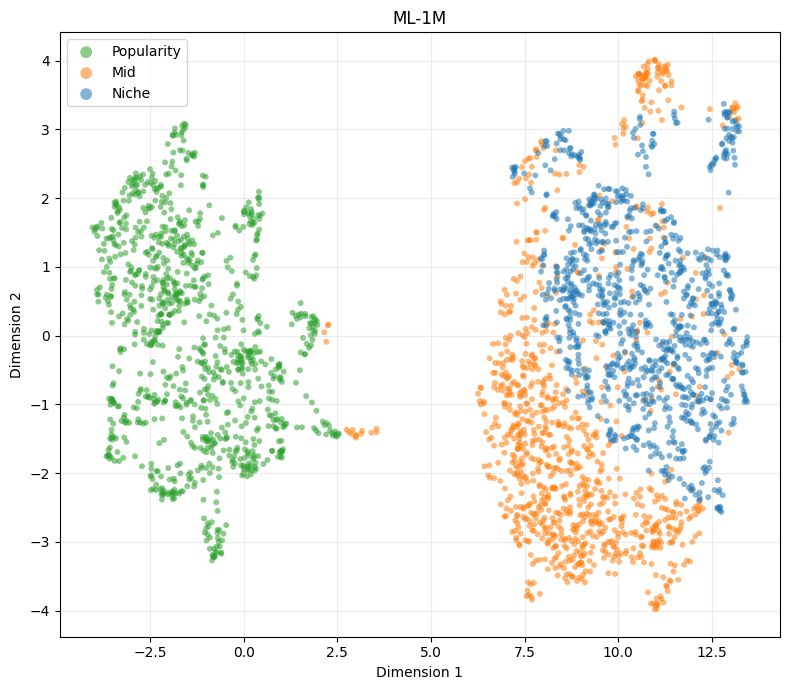

In [21]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap


@torch.no_grad()
def build_concept_samples(sasrec, concept_pools, concept_names,
                          n_synthetic_users=1000, seq_length=50,
                          device='cuda', batch_size=512, seed=42,
                          replace=False):
    """
    Like build_concept_activations, but returns the full [N, hidden_size]
    matrix per concept instead of the mean. Use this when you want a scatter
    plot (UMAP/t-SNE) rather than a single point per concept.

    Returns: dict {concept_name: tensor [n_synthetic_users, hidden_size]}
    """
    sasrec.eval()
    sasrec = sasrec.to(device)
    rng = np.random.default_rng(seed=seed)
    encode_fn = getattr(sasrec, '_encode', sasrec.forward)
    out = {}
    for concept_name in concept_names:
        if concept_name not in concept_pools:
            print(f"[skip] {concept_name}: not in concept_pools")
            continue
        pool_arr = np.array(list(concept_pools[concept_name]), dtype=np.int64)
        if len(pool_arr) == 0:
            print(f"[skip] {concept_name}: empty pool")
            continue

        if replace:
            seqs = rng.choice(pool_arr,
                              size=(n_synthetic_users, seq_length),
                              replace=True)
            seq_lens = np.full(n_synthetic_users, seq_length, dtype=np.int64)
        else:
            eff = min(seq_length, len(pool_arr))
            seqs = np.stack([
                rng.choice(pool_arr, size=eff, replace=False)
                for _ in range(n_synthetic_users)
            ])
            seq_lens = np.full(n_synthetic_users, eff, dtype=np.int64)

        all_h = []
        for start in range(0, n_synthetic_users, batch_size):
            end = min(start + batch_size, n_synthetic_users)
            item_seq     = torch.from_numpy(seqs[start:end]).long().to(device)
            item_seq_len = torch.from_numpy(seq_lens[start:end]).long().to(device)
            h = encode_fn(item_seq, item_seq_len)
            all_h.append(h.detach().cpu())

        out[concept_name] = torch.cat(all_h, dim=0)
        print(f"[done] {concept_name:<12s} shape={tuple(out[concept_name].shape)}")
    return out


def plot_popularity_umap(concept_samples,
                         tiers=('popularity', 'mid', 'niche'),
                         colors=('#2ca02c', '#ff7f0e', '#1f77b4'),
                         labels=('Popularity', 'Mid', 'Niche'),
                         n_neighbors=30,
                         min_dist=0.3,
                         metric='cosine',
                         seed=42,
                         figsize=(8, 7),
                         title='ML-1M'):
    """
    UMAP scatter of per-probe activation vectors, colored by popularity tier.
    """
    # stack with a label vector
    parts, group = [], []
    for tier in tiers:
        if tier not in concept_samples:
            print(f"[warn] {tier} not in concept_samples")
            continue
        H = concept_samples[tier].numpy()
        parts.append(H)
        group.extend([tier] * H.shape[0])
    X = np.concatenate(parts, axis=0)
    group = np.array(group)

    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist,
                        metric=metric, random_state=seed)
    emb = reducer.fit_transform(X)

    fig, ax = plt.subplots(figsize=figsize)
    for tier, color, label in zip(tiers, colors, labels):
        mask = group == tier
        ax.scatter(emb[mask, 0], emb[mask, 1],
                   s=18, alpha=0.55, color=color, label=label,
                   edgecolors='none')

    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.set_title(title)
    ax.legend(loc='best', frameon=True, markerscale=2)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    return emb, group


# Build per-probe activations for just the three popularity tiers
pop_samples = build_concept_samples(
    sasrec_model, concept_pools,
    concept_names=['popularity', 'mid', 'niche'],
    n_synthetic_users=1000, seq_length=50,
    device=device, batch_size=512,
)

# Plot
emb, group = plot_popularity_umap(pop_samples, title='ML-1M')

## using two concepts for steering

In [ ]:
def evaluate_with_recbole_sasrec(model, config, train_data, test_data):
    """Set steering on the model and run RecBole eval. Tier/genre/year exposure
    metrics are reported automatically alongside standard rec metrics."""
   
    model.steer_concept_idx = None
    model.steer_scale       = 1.0

    trainer = Trainer(config, model)
    trainer.eval_collector = Collector(config)
    trainer.evaluator      = Evaluator(config)
    trainer.eval_collector.data_collect(train_data)

    result = trainer.evaluate(test_data, load_best_model=False, show_progress=False)

 
    return result
def evaluate_with_recbole(cbm, config, train_data, test_data,
                          concept_idx=None, scale=1.0):
    """Set steering on the model and run RecBole eval. Tier/genre/year exposure
    metrics are reported automatically alongside standard rec metrics."""
    cbm.steer_concept_idx = concept_idx
    #config['steer_concept_idx'] = concept_idx
    cbm.steer_scale       = scale
    #config['steer_scale']       = scale
   

    trainer = Trainer(config, cbm)
    trainer.eval_collector = Collector(config)
    trainer.evaluator      = Evaluator(config)
    trainer.eval_collector.data_collect(train_data)

    result = trainer.evaluate(test_data, load_best_model=False, show_progress=False)

    cbm.steer_concept_idx = None
    #config['steer_concept_idx'] = None
    cbm.steer_scale       = 1.0
    #config['steer_scale' ]      = 1.0
    return result

In [ ]:
from recbole.quick_start import load_data_and_model

from recbole.utils.build_concepts import build_lookups

from recbole.evaluator import Collector, Evaluator


# Reset old steering
cbm_sasrec.steer_concept_idx = None
cbm_sasrec.steer_scale = 1.0

# Monkey-patch forward for multi-concept intervention
#original_forward = cbm_sasrec.forward.__func__  # get the unbound method

def patched_forward(self, item_seq, item_seq_len):
    h = self._encode(item_seq, item_seq_len)
    c_hat = self.concept_predictor(h)

    if hasattr(self, '_interventions') and self._interventions and not self.training:
        c_hat = c_hat.clone()
        for idx, scale in self._interventions.items():
            c_hat[:, idx] *= scale  # scale instead of set

    h_hat = self.reconstructor(c_hat)
    return h, c_hat, h_hat

import types
cbm_sasrec.forward = types.MethodType(patched_forward, cbm_sasrec)
cbm_sasrec._interventions = {}






concept_indx_1 = cbm_sasrec.concept_names.index('modern')
concept_indx_2  = cbm_sasrec.concept_names.index('classic')

cbm_sasrec._interventions = {
    concept_indx_1: 0.7,   
    concept_indx_2:  1.2,   
}




config['metrics']      = ['Recall', 'NDCG', 'MRR', 'Hit',
                          'ItemCoverage', 'GiniIndex',
                          'AveragePopularity', 'TierExposure', 'YearExposure', 'GenreExposure']

config['topk']         = [ 10]
config['valid_metric'] = 'NDCG@10'
config['eval_args']    = {'mode': 'full'}
config['tail_ratio']   = 0.2


L = build_lookups(dataset, config['dataset'])
config['popularity_pool'] = list(L['pop_set'])
config['mid_pool']        = list(L['mid_set'])
config['niche_pool']      = list(L['niche_set'])
config['item_to_genres']  = L['item_to_genres']
config['genre_list']      = L['genre_concepts']
config['item_to_era']     = L['item_to_era']


result_steered = evaluate_with_recbole(cbm_sasrec, config, train_data, test_data)

# Baseline
cbm_sasrec._interventions = {}
result_baseline = evaluate_with_recbole_sasrec(cbm_sasrec, config, train_data, test_data)

print(f"\n{'Metric':<35} {'Baseline':>12} {'Steered':>12} {'Δ':>12}")
print("─" * 73)
for k in sorted(result_baseline.keys()):
    b = result_baseline[k]
    s = result_steered[k]
    print(f"{k:<35} {b:>12.4f} {s:>12.4f} {s-b:>+12.4f}")

## Steering as Counterfactual Explanation

In [24]:
"""
Individual-user concept steering.

For a single user:
  1. Run the CBM, get c_hat (predicted concept activations).
  2. Pick the top-3 concepts by c_hat value.
  3. Suppress them (set to 0) — both individually and all-3-together.
  4. Re-generate top-20 recommendations from the suppressed c_hat.
  5. Measure how much the top-20 list changes (RBO / Jaccard / overlap),
     and which concepts moved.

This bypasses cbm_model.forward()'s built-in steering hook so the only
intervention applied is the one we control here.
"""

torch.manual_seed(42)
@torch.no_grad()
def _encode_user(cbm_model, interaction, device):
    """Return h, c_hat (UN-steered) for a one-row interaction."""
    item_seq     = interaction[cbm_model.ITEM_SEQ]
    item_seq_len = interaction[cbm_model.ITEM_SEQ_LEN]
    # call the encoder + predictor directly to skip forward()'s steering hook
    h = cbm_model._encode(item_seq, item_seq_len)
    c_hat = cbm_model.concept_predictor(h)
    return h, c_hat, item_seq, item_seq_len


@torch.no_grad()
def _scores_from_chat(cbm_model, c_hat):
    """c_hat -> h_hat -> full item scores [1, n_items]."""
    h_hat = cbm_model.reconstructor(c_hat)
    return h_hat @ cbm_model.item_embedding.weight.T


@torch.no_grad()
def steer_single_user(cbm_model, interaction, k=20, top_n=3,
                       use_ground_truth=False, device=None,
                       exclude_seen=True, verbose=True):
    """
    interaction : a SINGLE-row RecBole Interaction (one user's eval instance).
    k           : recommendation list length.
    top_n       : how many top concepts to suppress.
    use_ground_truth : if True, pick top concepts from gt concept vector
                       instead of c_hat. (Suppression still edits c_hat.)
    exclude_seen : mask items already in the user's history before ranking.

    Returns a dict with the baseline list, per-concept results, and the
    combined result.
    """
    if device is None:
        device = next(cbm_model.parameters()).device

    cbm_model.eval()
    interaction = interaction.to(device)

    h, c_hat, item_seq, item_seq_len = _encode_user(cbm_model, interaction, device)
    c_hat = c_hat.clone()                                  # [1, n_concepts]

    concept_names = getattr(cbm_model, 'concept_names', None)

    def name(i):
        return concept_names[i] if concept_names is not None else f"concept_{i}"


    # ── choose which concepts to suppress ────────────────────────────────────
    if use_ground_truth:
        ranking_vec = cbm_model._lookup_concepts(item_seq).clone()[0]
        rank_src = "ground-truth"
    else:
        ranking_vec = c_hat[0].clone()
        rank_src = "c_hat"
    top_idx = torch.topk(ranking_vec, top_n).indices.tolist()
    #top_idx = torch.topk(ranking_vec, top_n, largest=False).indices.tolist()
    #top_idx = torch.randperm(ranking_vec.numel())[:top_n].tolist()

    
    # ── seen-item mask ───────────────────────────────────────────────────────
    seen = set()
    if exclude_seen:
        seen = set(item_seq[0].detach().cpu().tolist()) - {0}

    def topk_from_scores(scores):
        s = scores.clone()
        if seen:
            s[0, list(seen)] = float('-inf')
        s[0, 0] = float('-inf')                            # padding item
        return torch.topk(s[0], k).indices.detach().cpu().tolist()

    # ── baseline (no suppression) ────────────────────────────────────────────
    base_scores = _scores_from_chat(cbm_model, c_hat)
    base_list   = topk_from_scores(base_scores)

    if verbose:
        print(f"\n{'='*64}")
        print(f"Single-user concept suppression  (rank source: {rank_src})")
        print(f"{'='*64}")
        print(f"  Top-{top_n} concepts to suppress:")
        for i in top_idx:
            print(f"    [{i:3d}] {name(i):<18s}  "
                  f"c_hat={c_hat[0, i].item():.4f}  "
                  f"gt={cbm_model._lookup_concepts(item_seq)[0, i].item():.4f}")

    def compare(new_list):
        sa, sb = set(base_list), set(new_list)
        inter = len(sa & sb)
        union = len(sa | sb)
        return {
            'list':     new_list,
            'rbo':       rbo.RankingSimilarity(base_list, new_list).rbo(),
            'jaccard':  inter / union if union else 0.0,
            'overlap':  inter,
            'changed':  k - inter,
        }

    results = {
        'top_concepts':  [(i, name(i), float(c_hat[0, i])) for i in top_idx],
        'baseline_list': base_list,
        'individual':    {},
        'combined':      None,
    }

    # ── individual suppression: one concept at a time ────────────────────────
    if verbose:
        print(f"\n  Individual suppression (one concept -> 0):")
    for i in top_idx:
        c_mod = c_hat.clone()
        c_mod[0, i] = 0

        r = compare(topk_from_scores(_scores_from_chat(cbm_model, c_mod)))
        results['individual'][i] = r
        if verbose:
            print(f"    {name(i):<18s}  "
                  f"RBO={r['rbo']:.4f}  Jaccard={r['jaccard']:.4f}  "
                  f"overlap={r['overlap']:2d}/{k}  changed={r['changed']:2d}")

    # ── combined suppression: all top_n at once ──────────────────────────────
    c_mod = c_hat.clone()
    for i in top_idx:
        c_mod[0, i] = 0
     

    rc = compare(topk_from_scores(_scores_from_chat(cbm_model, c_mod)))
    results['combined'] = rc
    if verbose:
        print(f"\n  Combined suppression (all {top_n} -> 0):")
        print(f"    RBO={rc['rbo']:.4f}  Jaccard={rc['jaccard']:.4f}  "
              f"overlap={rc['overlap']:2d}/{k}  changed={rc['changed']:2d}")
        print(f"{'='*64}\n")

    return results











@torch.no_grad()
def steer_population(cbm_model, data_loader, k=20, top_n=3,
                     use_ground_truth=False, max_users=None, device=None):
    
    """
    Run steer_single_user over many users and aggregate.
    Iterates the loader row-by-row so each user is steered by *their own*
    top concepts. Returns arrays of combined-suppression metrics.
    """

    if device is None:
        device = next(cbm_model.parameters()).device
    cbm_model.eval()

    rbo_all, jac_all, chg_all = [], [], []
    n_done = 0

    for batch in data_loader:
        interaction = batch[0] if isinstance(batch, (list, tuple)) else batch
        interaction = interaction.to(device)
        B = interaction[cbm_model.ITEM_SEQ].shape[0]

        for b in range(B):
            row = interaction[b:b + 1]
            r = steer_single_user(
                cbm_model, row, k=k, top_n=top_n,
                use_ground_truth=use_ground_truth,
                device=device, verbose=False,
            )
            c = r['combined']
            rbo_all.append(c['rbo'])
            jac_all.append(c['jaccard'])
            chg_all.append(c['changed'])
            n_done += 1
            if max_users is not None and n_done >= max_users:
                break
        if max_users is not None and n_done >= max_users:
            break

    rbo_all = np.array(rbo_all)
    jac_all = np.array(jac_all)
    chg_all = np.array(chg_all)

    print(f"\n{'='*64}")
    print(f"Population steering summary  "
          f"(top-{top_n} suppressed, combined, N={n_done})")
    print(f"{'='*64}")
    print(f"  Mean RBO vs baseline:    {rbo_all.mean():.4f}  "
          f"(1.0 = no change, lower = bigger change)")
    print(f"  Median RBO:              {np.median(rbo_all):.4f}")
    print(f"  Mean Jaccard:            {jac_all.mean():.4f}")
    print(f"  Mean items changed /{k}:  {chg_all.mean():.2f}")
    print(f"  Users w/ >=1 change:     {(chg_all > 0).sum()} / {n_done} "
          f"({100*(chg_all>0).mean():.1f}%)")
    print(f"  Users w/ identical list: {(chg_all == 0).sum()} / {n_done}")
    print(f"{'='*64}\n")

    return {'rbo': rbo_all, 'jaccard': jac_all, 'changed': chg_all}

In [ ]:
# ---- single user ----
batch = next(iter(test_data))
interaction = batch[0] if isinstance(batch, (list, tuple)) else batch
one_user = interaction[234:235]

res = steer_single_user(cbm_sasrec, one_user, k=20, top_n=3,
                        use_ground_truth=False)   # top-3 by c_hat

combined = res['combined']     # <-- this is your "all 3 at once" result
print(combined['rbo'], combined['jaccard'], combined['changed'])

In [ ]:
x=steer_population(cbm_sasrec, test_data, k=20, top_n=3,
                     use_ground_truth=False, max_users=None, device=None)

## steering for individual users

In [22]:
@torch.no_grad()
def steer_user_concept_exposure(cbm_model, interaction, concept_idx,
                                 k=20, top_changes=10, device=None,
                                 exclude_seen=True, verbose=True):
    """
    Suppress a SPECIFIED concept for one user and report:
      - top-k list before vs after (RBO / Jaccard / overlap)
      - mean concept exposure across the top-k items, before vs after

    interaction  : single-row RecBole Interaction (one user).
    concept_idx  : int or list[int] — concept(s) to suppress to 0.
    k            : recommendation list length.
    top_changes  : how many concepts to display in the exposure table,
                   ranked by |Δ exposure|. The suppressed concept(s) are
                   always shown regardless of rank.

    Returns a dict with the lists, list-change metrics, and the full
    per-concept exposure arrays (baseline, steered, delta).
    """
    
    if device is None:
        device = next(cbm_model.parameters()).device

    cbm_model.eval()
    interaction = interaction.to(device)

    # normalize concept_idx to a list
    if isinstance(concept_idx, int):
        suppressed = [concept_idx]
    else:
        suppressed = list(concept_idx)

    # encode user -> c_hat (un-steered)
    h, c_hat, item_seq, item_seq_len = _encode_user(cbm_model, interaction, device)
    c_hat = c_hat.clone()
    n_concepts = c_hat.shape[1]

    concept_names = getattr(cbm_model, 'concept_names', None)
    def name(i):
        return concept_names[i] if concept_names is not None else f"concept_{i}"

    # seen-item mask + padding
    seen = set()
    if exclude_seen:
        seen = set(item_seq[0].detach().cpu().tolist()) - {0}

    def topk_from_scores(scores):
        s = scores.clone()
        if seen:
            s[0, list(seen)] = float('-inf')
        s[0, 0] = float('-inf')
        return torch.topk(s[0], k).indices.detach().cpu().tolist()

    def exposure_for_items(item_ids):
        """Mean ground-truth concept vector across the given item IDs. -> [n_concepts]"""
        ids = torch.tensor(item_ids, device=device).unsqueeze(0)   # [1, k]
        c_items = cbm_model._lookup_concepts(ids)
        #print(f"item_ids {ids.shape}")
        
        if c_items.dim() == 3:
            # [batch, seq_len, n_concepts] -> mean over seq_len
            return c_items[0].mean(dim=0)                          # [n_concepts]
        elif c_items.dim() == 2:
            # [batch, n_concepts] — already aggregated. Fall back to
            # looking up each item individually so we can average ourselves.
            per_item = torch.stack([
                cbm_model._lookup_concepts(
                    torch.tensor([[iid]], device=device)
                ).squeeze(0).squeeze(0)                            # -> [n_concepts]
                for iid in item_ids
            ])    
            return per_item.mean(dim=0) 
            #return c_items.squeeze(0)                          # [n_concepts]
        else:
            raise RuntimeError(f"Unexpected _lookup_concepts shape: {tuple(c_items.shape)}")
    # ── baseline ─────────────────────────────────────────────────────────────
    base_scores = _scores_from_chat(cbm_model, c_hat)
    base_list   = topk_from_scores(base_scores)
    print(f"base_list{base_list}")
    ids = torch.tensor(base_list, device=device).unsqueeze(0)
    print(f"base_list_concept {cbm_sasrec._lookup_concepts(ids)}")
    base_exp    = exposure_for_items(base_list)                    # [n_concepts]

    # ── steered ──────────────────────────────────────────────────────────────
    c_mod = c_hat.clone()
    for i in suppressed:
        #print(f"Suppressing concept {i} {c_mod}")
        c_mod[0, i] = 0
        #print(f"supresed concept {i} {c_mod}")


    steer_scores = _scores_from_chat(cbm_model, c_mod)
    steer_list   = topk_from_scores(steer_scores)
    steer_exp    = exposure_for_items(steer_list)

    # ── list-change metrics ──────────────────────────────────────────────────
    sa, sb = set(base_list), set(steer_list)
    inter, union = len(sa & sb), len(sa | sb)
    list_metrics = {
        'rbo':     rbo.RankingSimilarity(base_list, steer_list).rbo(),
        'jaccard': inter / union if union else 0.0,
        'overlap': inter,
        'changed': k - inter,
    }

    # ── per-concept exposure delta ───────────────────────────────────────────
    delta = (steer_exp - base_exp).detach().cpu().numpy()
    base_np  = base_exp.detach().cpu().numpy()
    steer_np = steer_exp.detach().cpu().numpy()

    # rank concepts by absolute exposure change
    order = np.argsort(-np.abs(delta))
    # always include suppressed concepts in the display, even if Δ is small
    display = list(suppressed) + [i for i in order.tolist() if i not in suppressed]
    #display = display[: max(top_changes, len(suppressed))]

    if verbose:
        print(f"\n{'='*72}")
        print(f"Individual steering — suppress concept(s): "
              f"{[(i, name(i)) for i in suppressed]}")
        print(f"{'='*72}")

        print(f"\n  List change (top-{k}):")
        print(f"    RBO={list_metrics['rbo']:.4f}  "
              f"Jaccard={list_metrics['jaccard']:.4f}  "
              f"overlap={list_metrics['overlap']:2d}/{k}  "
              f"changed={list_metrics['changed']:2d}")

        print(f"    {'idx':>4s}  {'concept':<22s}  {'before':>9s}  "
              f"{'after':>9s}  {'delta':>9s}")
        print(f"    {'-'*4}  {'-'*22}  {'-'*9}  {'-'*9}  {'-'*9}")
        for i in display:
            mark = '*' if i in suppressed else ' '
            print(f"   {mark}[{i:3d}] {name(i):<22s}  "
                  f"{base_np[i]:9.4f}  {steer_np[i]:9.4f}  "
                  f"{delta[i]:+9.4f}")
        print(f"{'='*72}\n")

    return {
        'suppressed':   suppressed,
        'baseline_list':  base_list,
        'steered_list':   steer_list,
        'list_metrics':   list_metrics,
        'baseline_exposure': base_np,    # [n_concepts]
        'steered_exposure':  steer_np,   # [n_concepts]
        'delta_exposure':    delta,      # [n_concepts]
    }

In [23]:
# Suppress concept index 42 for one user
# ---- single user ----
batch = next(iter(test_data))
interaction = batch[0] if isinstance(batch, (list, tuple)) else batch
one_user = interaction[23:24]
r = steer_user_concept_exposure(cbm_sasrec, one_user,
                                concept_idx=15, k=20)



NameError: name '_encode_user' is not defined

In [ ]:
L['concept_names'].index('mid')

In [ ]:
L['concept_names'].index('popularity')